In [12]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [14]:
df = pd.read_csv("cupid_algorithm_dataset.csv")

In [15]:
df.head()

,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68


In [16]:
df['a_career_field'].value_counts()

a_career_field
Finance             10169
Engineering         10045
Education           10043
Law                 10036
Creative Arts        9997
Entrepreneurship     9981
Tech                 9964
Healthcare           9957
Marketing            9951
Science              9857
Name: count, dtype: int64

In [17]:
df['a_love_language'].value_counts()

a_love_language
Words of Affirmation    20160
Quality Time            20095
Receiving Gifts         19991
Physical Touch          19888
Acts of Service         19866
Name: count, dtype: int64

In [18]:
df.isnull().sum()

pair_id                          0
a_age                            0
a_education                      0
a_location                       0
a_career_field                   0
a_career_ambition                0
a_openness                       0
a_extraversion                   0
a_agreeableness                  0
a_conscientiousness              0
a_chronotype                     0
a_spontaneity                    0
a_love_language                  0
a_emotional_expressiveness       0
b_age                            0
b_education                      0
b_location                       0
b_career_field                   0
b_career_ambition                0
b_openness                       0
b_extraversion                   0
b_agreeableness                  0
b_conscientiousness              0
b_chronotype                     0
b_spontaneity                    0
b_love_language                  0
b_emotional_expressiveness       0
compatibility_score              0
compatible          

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.shape

(100000, 30)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          100000 non-null  int64  
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  object 
 4   a_career_field                 100000 non-null  object 
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float64
 11  a_spontaneity                  100000 non-null  float64
 12  a_love_language                

In [22]:
object_cols = df.select_dtypes(include='object').columns

In [23]:
df = pd.get_dummies(df, columns=object_cols, dtype='int8',drop_first=False)

In [24]:
df.shape

(100000, 60)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 60 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   pair_id                               100000 non-null  int64  
 1   a_age                                 100000 non-null  int64  
 2   a_education                           100000 non-null  int64  
 3   a_career_ambition                     100000 non-null  float64
 4   a_openness                            100000 non-null  float64
 5   a_extraversion                        100000 non-null  float64
 6   a_agreeableness                       100000 non-null  float64
 7   a_conscientiousness                   100000 non-null  float64
 8   a_chronotype                          100000 non-null  float64
 9   a_spontaneity                         100000 non-null  float64
 10  a_emotional_expressiveness            100000 non-null  float64
 11  b

<Axes: >

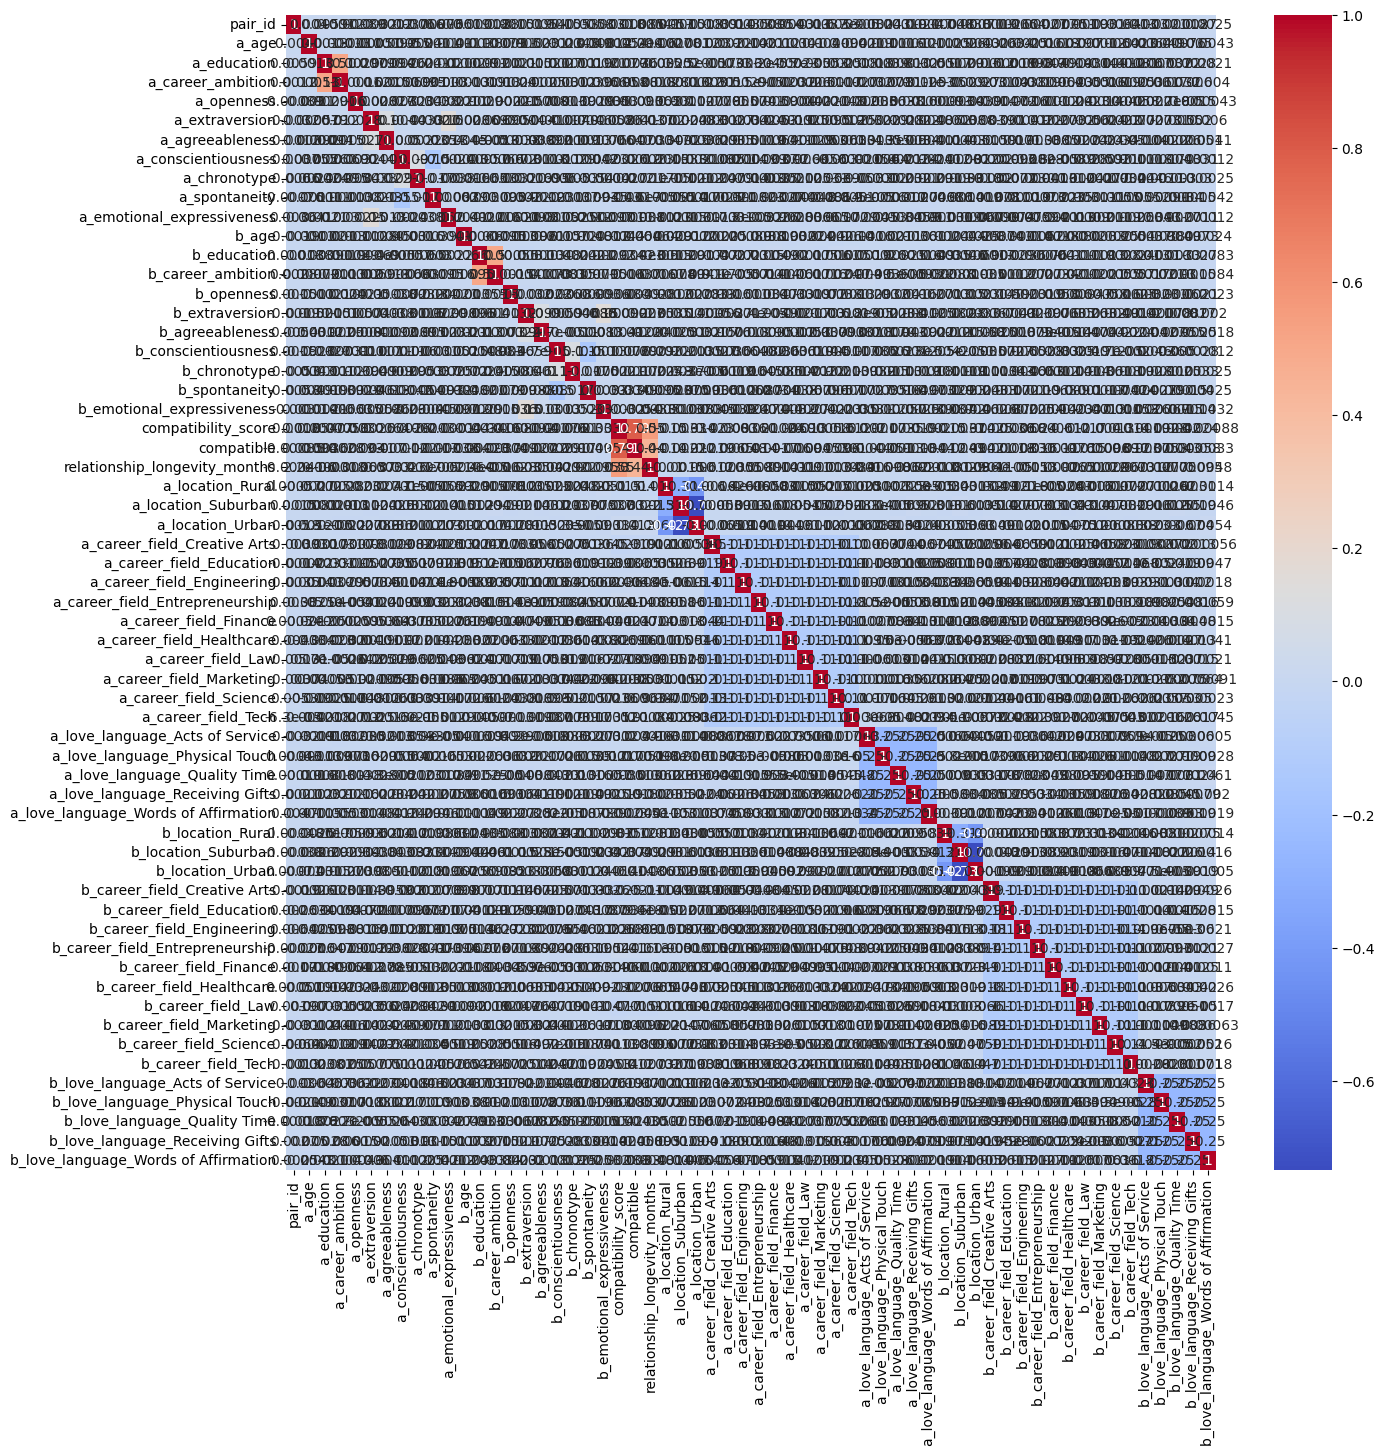

In [26]:
cor=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(cor, annot=True, cmap='coolwarm')

In [27]:
X = df.drop(columns='compatible')
y = df['compatible']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [29]:
from sklearn.feature_selection import mutual_info_regression

mutual_info = mutual_info_regression(X_train, y_train)

In [30]:
mutual_info

array([2.69301291e-03, 1.54264521e-03, 0.00000000e+00, 2.30568253e-03,
       6.89435875e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 2.75707739e-05, 8.47698632e-03, 0.00000000e+00,
       0.00000000e+00, 1.39456949e-03, 3.48499808e-03, 5.41459476e-04,
       0.00000000e+00, 6.40408910e-04, 4.43268224e-03, 5.47274088e-03,
       5.93300655e-03, 6.82267557e-01, 1.03518906e-01, 7.08901479e-04,
       5.00461195e-04, 0.00000000e+00, 7.92286857e-03, 4.09652147e-03,
       3.34872769e-03, 3.01902768e-03, 3.22509229e-03, 0.00000000e+00,
       2.05511047e-03, 2.31799105e-03, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 6.58332528e-04, 0.00000000e+00, 1.16949890e-03,
       0.00000000e+00, 4.29786988e-04, 5.81653736e-04, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.09159859e-03,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.41682365e-03,
       6.81843473e-04, 0.00000000e+00, 0.00000000e+00, 4.01859948e-04,
      

In [31]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mi=mutual_info.sort_values(ascending=False).head(39)
mi

compatibility_score                0.682268
relationship_longevity_months      0.103519
a_emotional_expressiveness         0.008477
a_career_field_Creative Arts       0.007923
a_openness                         0.006894
b_emotional_expressiveness         0.005933
b_spontaneity                      0.005473
b_chronotype                       0.004433
a_career_field_Education           0.004097
b_openness                         0.003485
b_career_field_Marketing           0.003417
a_career_field_Engineering         0.003349
a_career_field_Finance             0.003225
a_career_field_Entrepreneurship    0.003019
pair_id                            0.002693
a_career_field_Marketing           0.002318
a_career_ambition                  0.002306
b_love_language_Receiving Gifts    0.002148
a_career_field_Law                 0.002055
a_age                              0.001543
b_career_ambition                  0.001395
a_love_language_Receiving Gifts    0.001169
b_career_field_Entrepreneurship 

In [32]:
top_features = mi.index

In [33]:
X_train = X_train[top_features]
X_test = X_test[top_features]

<Axes: >

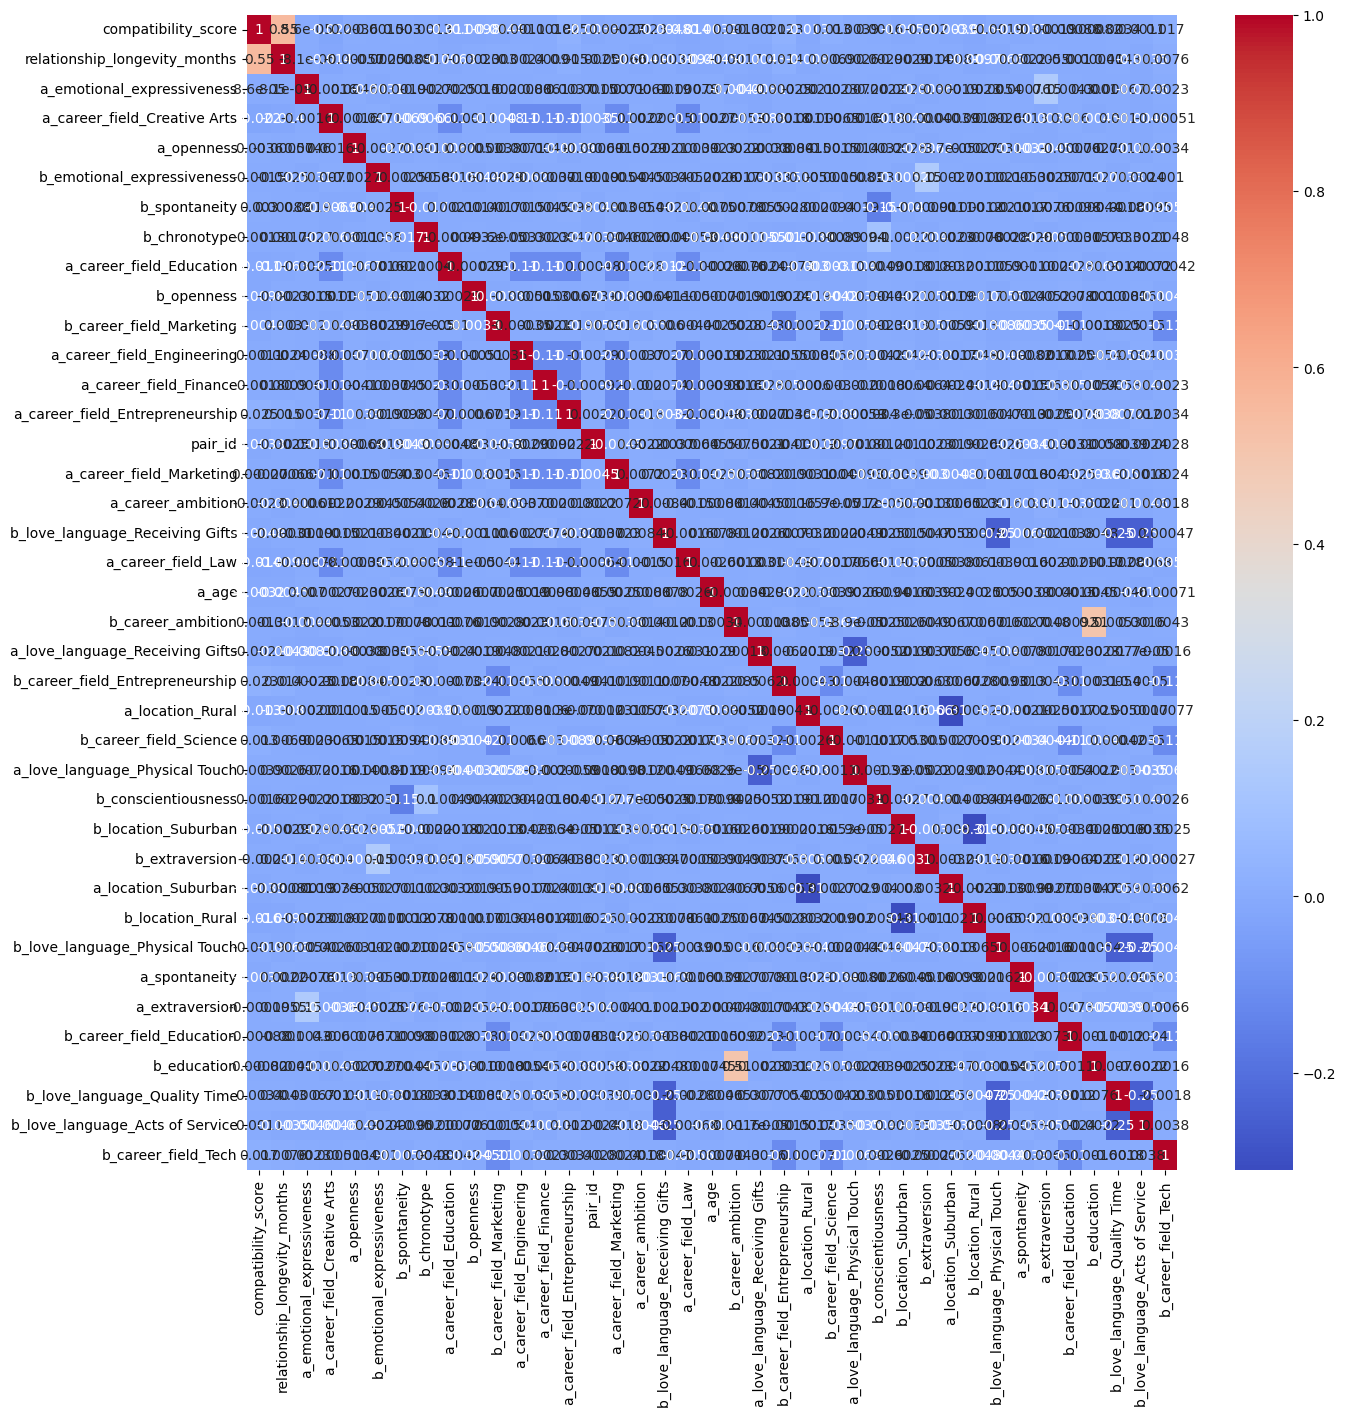

In [34]:
c=X_train.corr()
plt.figure(figsize=(15,15))
sns.heatmap(c, annot=True, cmap='coolwarm')

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

In [36]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
y_pred=lr.predict(X_test)

In [38]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

cr=classification_report(y_test,y_pred)
accu=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.81      0.79      0.80     11424
           1       0.73      0.75      0.74      8576

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



In [39]:
print(accu)

0.77315


In [40]:
print(cm)

[[9024 2400]
 [2137 6439]]
